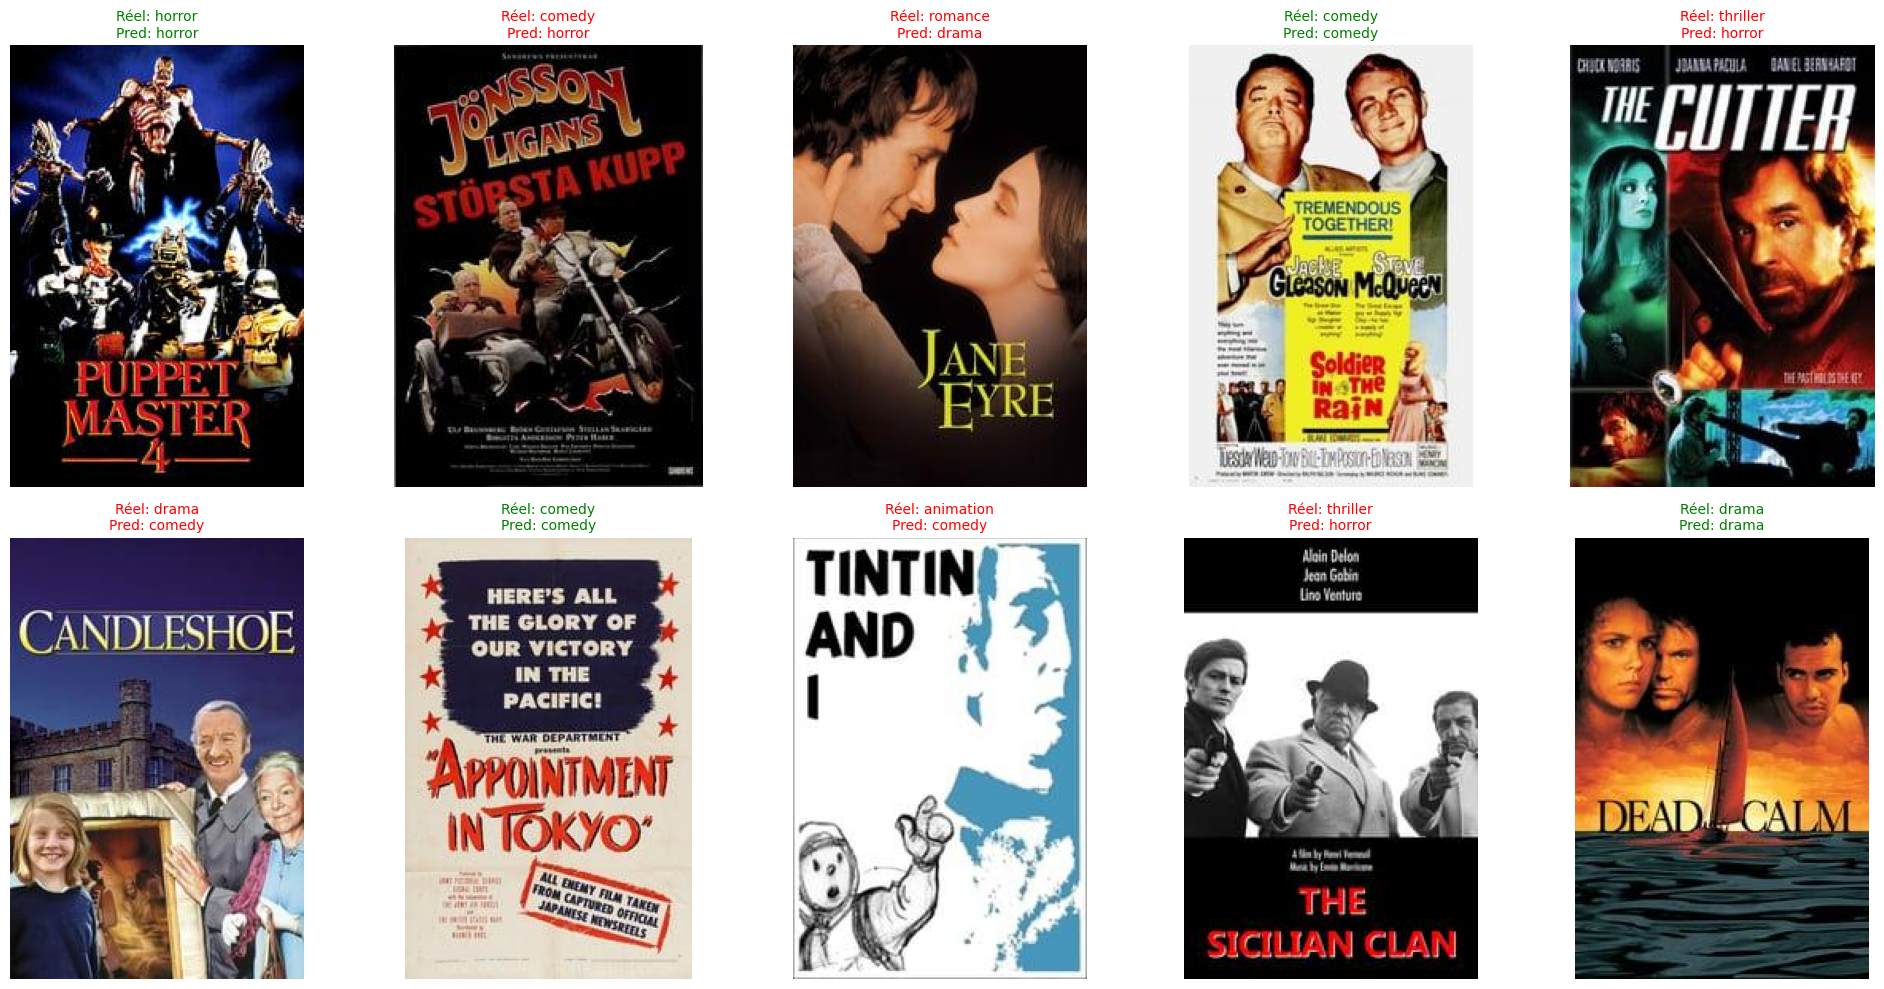

In [1]:
import requests
import os
import random
import matplotlib.pyplot as plt
from PIL import Image
import io

# 1. Configuration
API_URL = "http://localhost:5075/predict"
DATASET_PATH = "../sorted_movie_posters_paligema"

# 2. Récupération de tous les chemins d'images
all_images = []
for root, dirs, files in os.walk(DATASET_PATH):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
            full_path = os.path.join(root, file)
            # On extrait le genre à partir du nom du dossier parent
            genre_reel = os.path.basename(root)
            all_images.append((full_path, genre_reel))

# 3. Sélection de 10 posters au hasard
test_samples = random.sample(all_images, 10)

# 4. Affichage des résultats
plt.figure(figsize=(20, 10))

for i, (img_path, ground_truth) in enumerate(test_samples):
    # Lecture et envoi de l'image à l'API
    with open(img_path, "rb") as f:
        img_data = f.read()
    
    try:
        response = requests.post(API_URL, data=img_data)
        prediction = response.json().get('label', 'Erreur')
    except Exception as e:
        prediction = "API Down"

    # Affichage
    img = Image.open(img_path)
    plt.subplot(2, 5, i + 1)
    plt.imshow(img)
    
    # Couleur du titre : vert si correct, rouge si erreur
    color = 'green' if prediction == ground_truth else 'red'
    
    plt.title(f"Réel: {ground_truth}\nPred: {prediction}", color=color, fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()